# 05 — Market research, step by step

A simple look at the data we already downloaded. **No new downloads and no backtest.**

Run each code cell with **Shift+Enter**:

1. Load the data.
2. Count what we have.
3. Compare the markets.
4. See which dates have prices.
5. Define one short plotting function.
6. Plot Hormuz.
7. Plot Russia–Ukraine.

The charts now give **each volume panel its own vertical scale**, so smaller markets are visible. Read the axis values when comparing volume.

**Sections 8-12** compare Hormuz volume, deadline curves and daily price changes. **Sections 13-20** separate intraday follow-through, reversal and trade flow, then add a curved fit. **New sections 21-24** explain the two-leg payoff and screen saved prices for deadline-pair arbitrage candidates.


### 1. Load the saved data

`contracts` describes the markets. `prices` contains price observations. `trades` contains individual fills. Dates use UTC.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Find the repository from this notebook's folder.
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

latest = json.loads((ROOT / "data/research/deadline_markets/step2/latest.json").read_text())
DATA = ROOT / latest["job_path"]
manifest = json.loads((DATA / "manifest.json").read_text())

contracts = pd.read_parquet(DATA / "contracts.parquet").sort_values(["family", "deadline_date"])
prices = pd.read_parquet(DATA / "tables/prices.parquet")
trades = pd.read_parquet(DATA / "tables/trades.parquet")
prices["day"] = prices["timestamp_utc"].dt.floor("D")
trades["day"] = trades["timestamp_utc"].dt.floor("D")

family_names = {"hormuz_normalisation": "Hormuz", "russia_ukraine_agreement": "Russia–Ukraine"}
contracts["label"] = contracts["family"].map(family_names) + " · " + pd.to_datetime(contracts["deadline_date"]).dt.strftime("%b %d")

print("Data saved through:", manifest["frozen_end_utc"])
print("Download status:", manifest["status"])


Data saved through: 2026-10-03T13:57:14+00:00
Download status: complete_api_walks


### 2. How much data do we have?

An **event** is Polymarket's grouping; a **market** is one question with one deadline. “Days” below means UTC dates with at least one record, not complete 24-hour coverage.


In [2]:
markets_per_day = prices.groupby("day")["market_id"].nunique()

overview = pd.Series({
    "Research families": contracts["family"].nunique(),
    "Polymarket events": contracts["event_id"].nunique(),
    "Deadline markets": contracts["market_id"].nunique(),
    "Outcome tokens": prices["token_id"].nunique(),
    "Price observations": len(prices),
    "Individual trades": len(trades),
    "Days with prices": prices["day"].nunique(),
    "Days with trades": trades["day"].nunique(),
    "Dates with prices in every market": markets_per_day.eq(len(contracts)).sum(),
})
display(overview.to_frame("Count"))
print("Price dates:", prices["day"].min().date(), "to", prices["day"].max().date())


,Count
Research families,2
Polymarket events,5
Deadline markets,7
Outcome tokens,14
Price observations,416372
Individual trades,96092
Days with prices,145
Days with trades,146
Dates with prices in every market,27


Price dates: 2026-05-12 to 2026-10-03


### 3. Counts and coverage for each market

Counts include **Yes and No**. Price rows can overlap across resolutions, so they are not independent quotes.

`total_notional` = sum of **trade price × shares traded**. This is the volume measure plotted below; it is not the number of trades or liquidity.


In [3]:
summary = contracts[["market_id", "label"]].set_index("market_id")
summary["price_rows"] = prices.groupby("market_id").size()
summary["trades"] = trades.groupby("market_id").size()
summary["price_days"] = prices.groupby("market_id")["day"].nunique()
summary["trade_days"] = trades.groupby("market_id")["day"].nunique()
summary["first_price"] = prices.groupby("market_id")["day"].min().dt.date
summary["last_price"] = prices.groupby("market_id")["day"].max().dt.date
summary["total_notional"] = trades.groupby("market_id")["notional_price_times_size"].sum().round(2)

display(summary)


,label,price_rows,trades,price_days,trade_days,first_price,last_price,total_notional
market_id,,,,,,,,
2774057,Hormuz · Sep 30,64205,16161,93,94,2026-07-03,2026-10-03,4808467.01
3501950,Hormuz · Oct 31,59039,2430,54,54,2026-08-11,2026-10-03,514884.61
3501951,Hormuz · Nov 30,59104,1399,54,54,2026-08-11,2026-10-03,180945.16
2176270,Hormuz · Dec 31,64557,33911,145,146,2026-05-12,2026-10-03,6211360.71
2243896,Russia–Ukraine · Oct 31,64458,11309,144,144,2026-05-13,2026-10-03,772490.70
4338145,Russia–Ukraine · Nov 30,40438,196,27,27,2026-09-07,2026-10-03,16735.35
2243897,Russia–Ukraine · Dec 31,64571,30686,144,144,2026-05-13,2026-10-03,1352693.53


### 4. Which dates have prices?

Each mark means at least one saved price observation that day. It does **not** mean uninterrupted data or active trading all day.


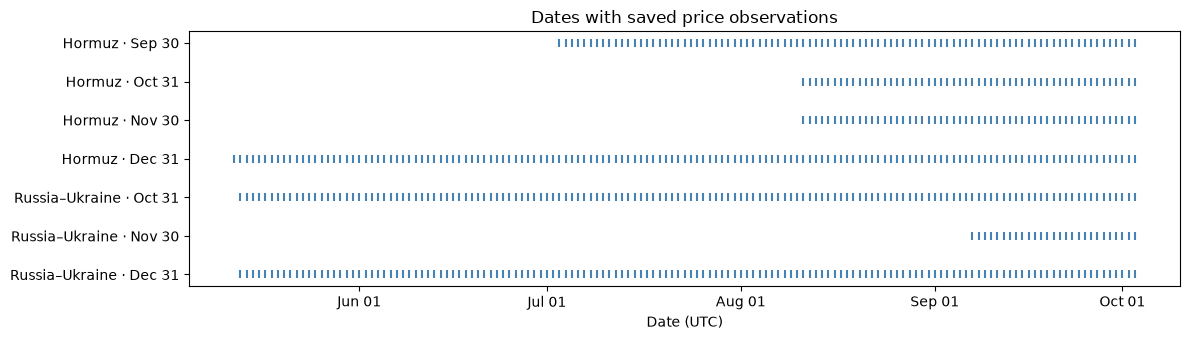

In [4]:
fig, ax = plt.subplots(figsize=(12, 3.5))
for row, market_id in enumerate(contracts["market_id"]):
    days = prices.loc[prices["market_id"].eq(market_id), "day"].drop_duplicates()
    ax.scatter(days, [row] * len(days), marker="|", color="steelblue")

ax.set_yticks(range(len(contracts)), contracts["label"])
ax.invert_yaxis()
ax.set(title="Dates with saved price observations", xlabel="Date (UTC)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.tight_layout()
plt.show()


### 5. Simple price and volume plots

This is the only plotting function; we reuse it for the two families.

- **Top:** YES-price observations, in cents. Dots avoid drawing lines through gaps. These combine the retained 1-minute, 5-minute, 30-minute and 3-hour data.
- **Bottom:** daily traded notional, in **thousands**, summed across both outcomes.
- **Each volume axis has its own scale.** Equal bar heights in different panels do not mean equal volume.
- Bars appear only on days with returned trades. Blank periods before listing are not zero-volume observations.

The last collection day is partial. Records after expired deadlines are still included; these are descriptive charts, not a backtest.


In [5]:
yes_prices = prices[prices["outcome"].eq("Yes")]
daily_volume = trades.groupby(["market_id", "day"])["notional_price_times_size"].sum().reset_index(name="notional")
deadlines = sorted(contracts["deadline_date"].unique())
plot_start = min(prices["day"].min(), trades["day"].min())
plot_end = pd.Timestamp(manifest["frozen_end_utc"]).ceil("D")

def plot_markets(family):
    fig, axes = plt.subplots(2, len(deadlines), figsize=(16, 6))
    for column, deadline in enumerate(deadlines):
        matching = contracts[contracts["family"].eq(family) & contracts["deadline_date"].eq(deadline)]
        price_ax, volume_ax = axes[:, column]
        price_ax.set_title(pd.Timestamp(deadline).strftime("%B %d"))

        if matching.empty:
            price_ax.text(0.5, 0.5, "No matching market", ha="center", transform=price_ax.transAxes)
            price_ax.set_axis_off()
            volume_ax.set_axis_off()
            continue

        market_id = matching.iloc[0]["market_id"]
        market_prices = yes_prices[yes_prices["market_id"].eq(market_id)]
        market_volume = daily_volume[daily_volume["market_id"].eq(market_id)]

        price_ax.scatter(market_prices["timestamp_utc"], market_prices["price"] * 100, s=2)
        price_ax.set(ylabel="YES price (cents)", ylim=(0, 100))
        volume_ax.bar(market_volume["day"], market_volume["notional"] / 1000, width=1, align="edge")
        volume_ax.set_ylabel("Daily notional (thousands)")
        volume_ax.set_ylim(bottom=0)  # No shared maximum: smaller markets remain visible.

        for ax in [price_ax, volume_ax]:
            ax.set_xlim(plot_start, plot_end)
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
            ax.tick_params(axis="x", labelrotation=30)
            ax.set_xlabel("Date (UTC)")

    fig.suptitle(f"{family_names[family]} — YES prices and daily traded volume\nVolume scales differ between panels")
    fig.tight_layout()
    plt.show()
    return fig


### 6. Hormuz

October and November **do have volume**. Both started trading on August 11, so earlier months are blank.

Their saved traded-notional totals are about **515,000** and **181,000**, compared with **4.81 million** for September and **6.21 million** for December. The previous shared volume scale made the smaller bars look almost flat.


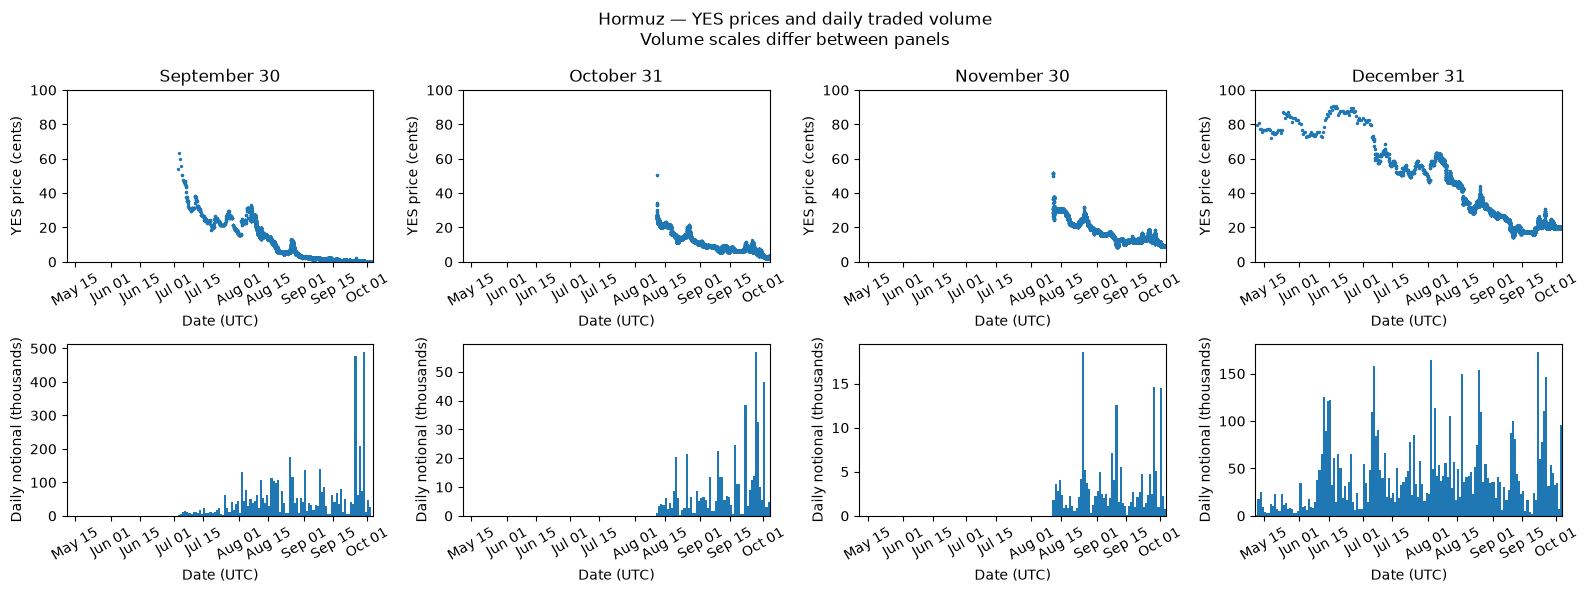

In [6]:
fig_hormuz = plot_markets("hormuz_normalisation")


### 7. Russia–Ukraine

November also has volume, but much less: **196 trades**, about **16,735** in traded notional. It started trading on September 7. October has 11,309 trades and about 772,491 in notional.

No matching September-deadline agreement market was found, so that panel stays explicitly unavailable.


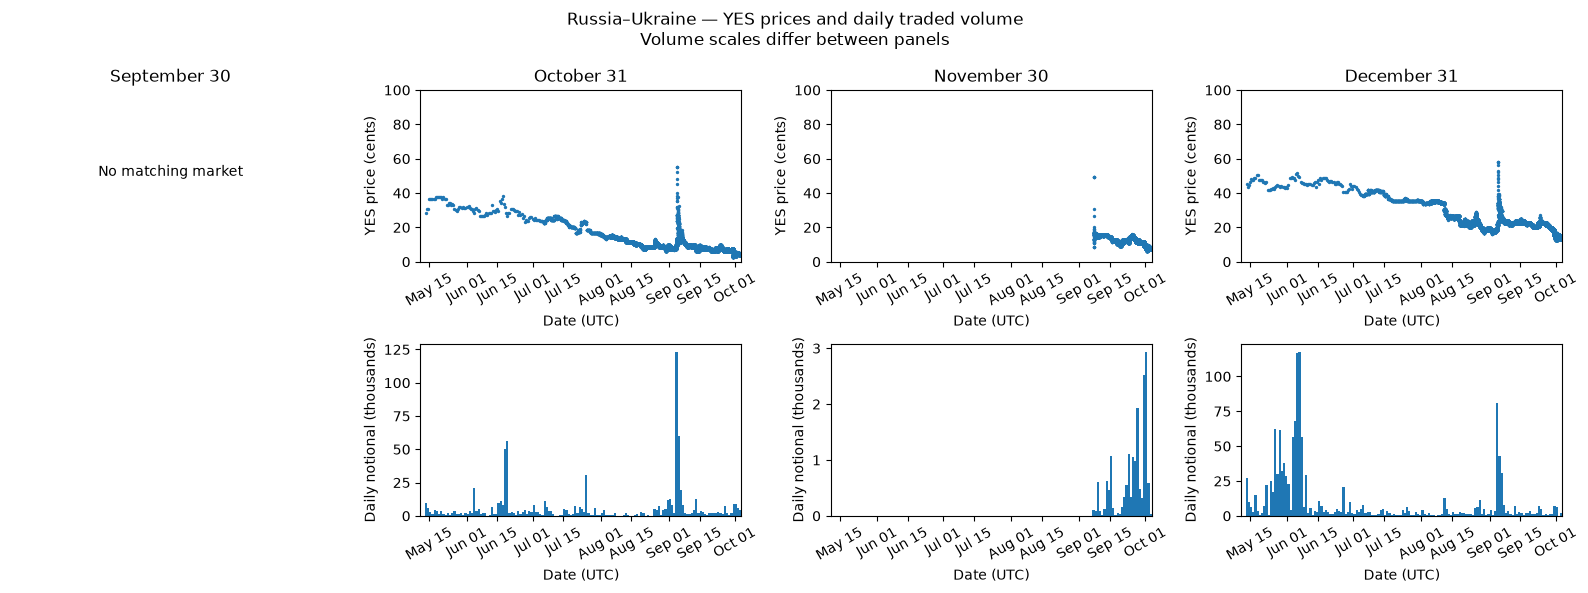

In [7]:
fig_ukraine = plot_markets("russia_ukraine_agreement")


### 8. Hormuz: why does December have more history and volume?

These are separately listed markets, not four series that all began together. December was created on May 6 and has trades from May 11; September began in July; October and November were created on August 10 and have trades from August 11.

More time allows more total volume, but it is not the whole explanation. The table below also compares **the same dates** for every market. Lower trade counts and traded value on those dates mean the October/November markets really are quieter in our saved data. The data does not tell us why traders preferred one deadline.

For the relationship check, start on the first full UTC day after all four began trading. Stop **before September 30**, conservatively excluding the entire September deadline day and everything after it. The Hormuz rules specify a date, not an exact intraday cutoff.


In [8]:
hormuz = contracts[contracts["family"].eq("hormuz_normalisation")].copy()
hormuz["month"] = pd.to_datetime(hormuz["deadline_date"]).dt.strftime("%b")
months = hormuz["month"].tolist()
month_by_id = hormuz.set_index("market_id")["month"]
common_start = hormuz["api_start_date_utc"].max().ceil("D")
common_end = min(pd.Timestamp(hormuz["deadline_date"].min(), tz="UTC"),
                 pd.Timestamp(manifest["frozen_end_utc"]).floor("D"))

hormuz_trades = trades[trades["family"].eq("hormuz_normalisation")]
window_trades = hormuz_trades[hormuz_trades["timestamp_utc"].ge(common_start)
                             & hormuz_trades["timestamp_utc"].lt(common_end)]
volume_comparison = hormuz.set_index("market_id")[["month"]].copy()
volume_comparison["created"] = hormuz.set_index("market_id")["market_created_at_utc"].dt.date
volume_comparison["first_saved_trade"] = hormuz_trades.groupby("market_id")["timestamp_utc"].min().dt.date
volume_comparison["trades_same_window"] = window_trades.groupby("market_id").size()
volume_comparison["notional_same_window"] = window_trades.groupby("market_id")["notional_price_times_size"].sum().round()
volume_comparison["notional_per_day"] = (volume_comparison["notional_same_window"]
                                        / (common_end - common_start).days).round()

print("Common window:", common_start.date(), "to", common_end.date(), "(end excluded)")
display(volume_comparison.set_index("month"))


Common window: 2026-08-12 to 2026-09-30 (end excluded)


,created,first_saved_trade,trades_same_window,notional_same_window,notional_per_day
month,,,,,
Sep,2026-07-02,2026-07-02,11530,3624601.0,73971.0
Oct,2026-08-10,2026-08-11,2098,454003.0,9265.0
Nov,2026-08-10,2026-08-11,1257,160668.0,3279.0
Dec,2026-05-06,2026-05-11,7393,2478307.0,50578.0


### 9. Compare Hormuz prices on the same dates

Use **YES prices only**, from one saved resolution: **5-minute**. Take the observation timestamped exactly **00:00 UTC** each day. This avoids mixing resolutions or comparing observations from different times of day.

Keep the full daily calendar. Missing observations stay missing: **no forward-fill or interpolation**. A missing midnight observation does not mean that the whole day has no data. Later, we calculate changes *before* dropping missing rows, so a two-day gap cannot become a one-day return.

These are sampled API history observations, not executable bid/ask quotes. The [API documentation](https://data-api.polymarket.com/v2/docs) and the saved `api_spec.json` describe their resolution. A daily check cannot tell us which market reacts first within seconds or minutes.


49 calendar dates; 46 have all four midnight prices.


,Missing midnight prices
month,
Sep,3
Oct,2
Nov,2
Dec,2


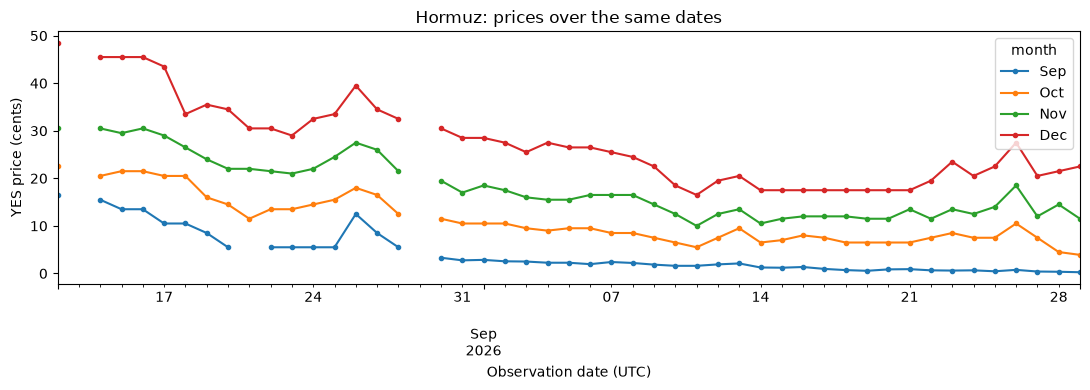

In [9]:
hormuz_prices = prices[prices["family"].eq("hormuz_normalisation")
                       & prices["outcome"].eq("Yes")
                       & prices["resolution_seconds"].eq(300)].copy()
hormuz_prices["month"] = hormuz_prices["market_id"].map(month_by_id)
midnight = hormuz_prices[hormuz_prices["timestamp_utc"].eq(hormuz_prices["day"])]
daily_prices = midnight.pivot(index="timestamp_utc", columns="month", values="price")
calendar = pd.date_range(common_start, common_end, freq="D", inclusive="left")
daily_prices = daily_prices.reindex(index=calendar, columns=months) * 100
complete_prices = daily_prices.dropna()

print(len(calendar), "calendar dates;", len(complete_prices), "have all four midnight prices.")
display(daily_prices.isna().sum().rename("Missing midnight prices").to_frame())
ax = daily_prices.plot(figsize=(11, 4), marker=".", title="Hormuz: prices over the same dates")
ax.set(xlabel="Observation date (UTC)", ylabel="YES price (cents)")
plt.tight_layout()
plt.show()


### 10. A simple curve across the four deadlines

At one observation time, put September, October, November and December on the horizontal axis and their YES prices on the vertical axis. That is the **deadline curve**, distinct from each market's price changing through time.

Below are the first, middle and last complete snapshots. Dots are observed prices; dashed lines are **straight-line least-squares fits**. With only four deadlines, start with this two-parameter baseline rather than fitting a complicated curve. The fit describes the shape on that date; it is not a forecast, a calibrated probability model or a reason to trade a deviation. An unconstrained line can dip below zero near September: that is a limitation of this simple fit, not a possible market price.

We also count how often the observed prices increase with the deadline. The rules share the same PortWatch threshold, but the qualifying window starts at each market's own creation date. They are **not automatically identical nested contracts**; an apparent ordering violation would need a rules review before calling it an arbitrage.


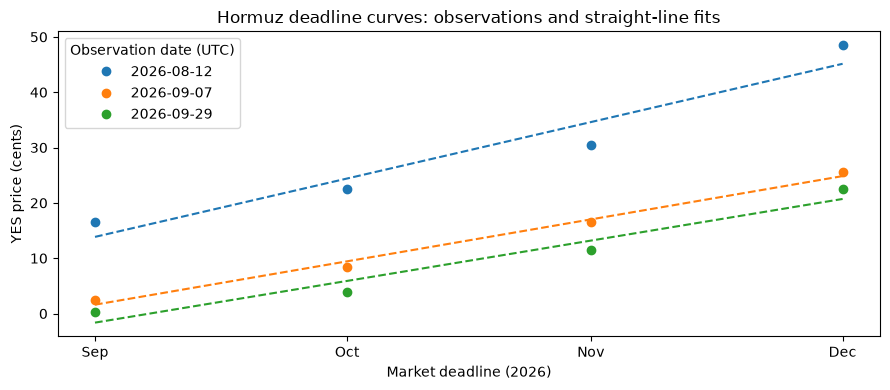

,Mean absolute fit error (cents)
2026-08-12,3.00
2026-09-07,0.73
2026-09-29,1.84


Later deadline prices were at least as high: 46 of 46 snapshots.


In [10]:
import numpy as np

deadline_dates = pd.to_datetime(hormuz["deadline_date"])
days_from_september = (deadline_dates - deadline_dates.iloc[0]).dt.days.to_numpy()
snapshot_dates = complete_prices.index[[0, len(complete_prices) // 2, -1]]
fig, ax = plt.subplots(figsize=(9, 4))
curve_errors = {}
for date in snapshot_dates:
    observed = complete_prices.loc[date].to_numpy()
    slope, intercept = np.polyfit(days_from_september, observed, 1)
    fitted = intercept + slope * days_from_september
    dots, = ax.plot(deadline_dates, observed, "o", label=str(date.date()))
    ax.plot(deadline_dates, fitted, "--", color=dots.get_color())
    curve_errors[str(date.date())] = np.abs(observed - fitted).mean()

ax.set_xticks(deadline_dates, months)
ax.set(xlabel="Market deadline (2026)", ylabel="YES price (cents)",
       title="Hormuz deadline curves: observations and straight-line fits")
ax.legend(title="Observation date (UTC)")
plt.tight_layout()
plt.show()
display(pd.Series(curve_errors, name="Mean absolute fit error (cents)").round(2).to_frame())
ordered = complete_prices.diff(axis=1).iloc[:, 1:].ge(0).all(axis=1)
print("Later deadline prices were at least as high:", ordered.sum(), "of", len(ordered), "snapshots.")


### 11. When September moves, do the others move too?

Compare **daily changes in cents**, not price levels. Otherwise, two prices drifting down over time could look strongly related without moving together day to day.

The scatter plots pair September's change with each later market's change over the **same 24 hours**. A fitted line sloping upward indicates positive association. Correlation runs from -1 to +1; it does not prove causation or predict the next move.

The table also repeats the correlation after removing the largest absolute September move, as a simple sensitivity check. The full sample remains the main result; we are not deleting data to improve the fit.


42 matched daily changes; largest September move: 2026-08-26


,same_day_correlation,without_largest_Sep_move
month,,
Oct,0.521,0.483
Nov,0.462,0.428
Dec,0.411,0.245


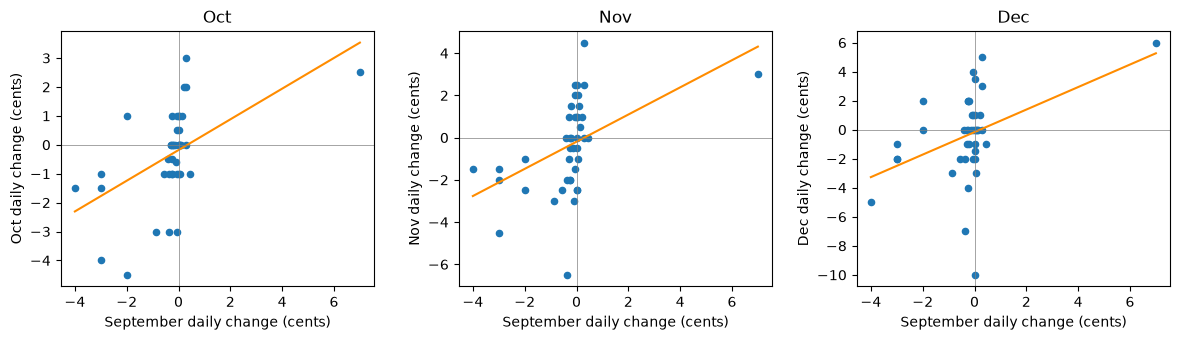

In [11]:
daily_changes = daily_prices.diff()
same_day = daily_changes.dropna()
later_months = months[1:]
largest_move_date = same_day["Sep"].abs().idxmax()
without_largest = same_day.drop(index=largest_move_date)
correlations = pd.DataFrame({
    "same_day_correlation": same_day[later_months].corrwith(same_day["Sep"]),
    "without_largest_Sep_move": without_largest[later_months].corrwith(without_largest["Sep"]),
})
print(len(same_day), "matched daily changes; largest September move:", largest_move_date.date())
display(correlations.round(3))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, month in zip(axes, later_months):
    x, y = same_day["Sep"], same_day[month]
    slope, intercept = np.polyfit(x, y, 1)
    line_x = np.array([x.min(), x.max()])
    ax.scatter(x, y, s=20)
    ax.plot(line_x, intercept + slope * line_x, color="darkorange")
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.axvline(0, color="grey", linewidth=0.5)
    ax.set(title=month, xlabel="September daily change (cents)",
           ylabel=f"{month} daily change (cents)")
plt.tight_layout()
plt.show()


### 12. Does a September rise come before a later market rises?

Separate **same-day co-movement** from **next-day follow-through**. At midnight on day t, September's change covers the preceding 24 hours. The next-day comparison uses the other market's change from t to t+1. Shift on the full calendar *before* dropping missing rows, so gaps never become fake one-day lags.

For a literal first check, "up" means **any positive price change**, including very small moves. Compare the percentage of up days after September rose with the other market's usual up-day percentage in the same valid sample. Flat days count as not up.

This is exploratory, in-sample analysis. Small samples, stale prices, spreads and transaction costs can all matter. There is no holdout test, significance claim or executable trading simulation here.


In [12]:
next_day = daily_changes[later_months].shift(-1).join(daily_changes["Sep"]).dropna()
sep_up_same = same_day["Sep"].gt(0)
sep_up_next = next_day["Sep"].gt(0)
print("Same day:", len(same_day), "pairs;", sep_up_same.sum(), "September-up days.")
print("Next day:", len(next_day), "pairs;", sep_up_next.sum(), "September-up days.")

up_check = pd.DataFrame({
    "same_day_corr": same_day[later_months].corrwith(same_day["Sep"]),
    "next_day_corr": next_day[later_months].corrwith(next_day["Sep"]),
    "same_day_up_if_Sep_up_%": same_day.loc[sep_up_same, later_months].gt(0).mean() * 100,
    "same_day_baseline_up_%": same_day[later_months].gt(0).mean() * 100,
    "next_day_up_if_Sep_up_%": next_day.loc[sep_up_next, later_months].gt(0).mean() * 100,
    "next_day_baseline_up_%": next_day[later_months].gt(0).mean() * 100,
})
display(up_check.round(3))


Same day: 42 pairs; 10 September-up days.
Next day: 40 pairs; 10 September-up days.


,same_day_corr,next_day_corr,same_day_up_if_Sep_up_%,same_day_baseline_up_%,next_day_up_if_Sep_up_%,next_day_baseline_up_%
Oct,0.521,0.139,50.0,28.571,20.0,27.5
Nov,0.462,0.082,70.0,35.714,30.0,37.5
Dec,0.411,0.061,40.0,30.952,30.0,32.5


### What this first check can tell us

Read the outputs in order:

1. Does December still have more traded value when the observation window is the same?
2. Do later deadlines usually have higher prices, and how close is a straight line to the observed curve?
3. Do **changes** move together over the same day?
4. After September rises, does the next-day up rate exceed the ordinary up rate?

For this saved dataset, the same-day correlations are positive, but the next-day correlations are much weaker. There are only **10 September-up days** in the valid daily sample, and the later markets' next-day up rates do **not** exceed their baselines. That is not evidence of a reliable "September rises, buy later deadlines" rule. It also does not rule out a faster intraday relationship; we have not tested that.

**Stop here and review together.** These results describe this historical window, not a normal relationship established across many periods. No data was downloaded or changed, and no trades were placed.


## Hormuz: three different hypotheses, tested separately

**First, what did "next day" mean?** The previous table compared September's change during one day with another market's change during the following day. December could already have reacted in the same day. A weak next-day correlation is not evidence of an unfilled gap.

September rising does **not** force December to rise. As a hypothetical example, news could change the chance of normal traffic by September from 10% to 20%, while leaving the chance by December at 40%: more likely *sooner*, not more likely *eventually*. Our contracts also start their qualifying windows on different creation dates.

Here are the questions we can actually check:

1. **Delayed response:** after a sharp September rise, do October/November/December rise afterward?
2. **Reversal:** does September instead fall back?
3. **Trade flow:** are the answers different when the rise has unusually high volume and YES-directed taker flow?

A temporary price difference is only a **candidate statistical signal**, not a locked-in arbitrage or a guaranteed convergence. Chart observations are not guaranteed execution prices; buying and selling crosses an order book. [Polymarket explains bids, asks and displayed prices here](https://docs.polymarket.com/concepts/prices-orderbook).

We have no timestamped news-event labels or wallet identities in these tables. A flagged jump is a **price event**, not proof of news, insider information or one wrong trader. We will inspect individual episodes, not attach a story after seeing the result.


### 13. The settings and a common 5-minute clock

Start with a transparent definition: September rises **2 cents in 15 minutes**. This is an absolute price move, not a 2% return. Examine 15 minutes, 1 hour and 6 hours afterward. These are starting choices, not parameters optimized for a good result.

Use only native 5-minute YES history, with no filling or interpolation. Delay each observation by one 5-minute slot as a conservative bucket-availability allowance. We do not know historical delivery latency exactly. Repeated prices may also be stale; a recorded point does not prove a fresh tradable quote.

The whole test remains before September's deadline. The extra 5-minute wait used later is a timing sensitivity, **not proof we could have executed**.


In [13]:
JUMP_CENTS = 2.0
HORIZONS_MINUTES = [15, 60, 360]
COOLDOWN_MINUTES = max(HORIZONS_MINUTES) + 20
HIGH_VOLUME_MULTIPLE = 3.0
MIN_FILLS = 10
YES_IMBALANCE = 0.5

grid = pd.date_range(common_start, common_end, freq="5min", inclusive="left")
aligned = hormuz_prices[hormuz_prices["timestamp_utc"].eq(
    hormuz_prices["timestamp_utc"].dt.floor("5min"))]
price5 = aligned.pivot(index="timestamp_utc", columns="month", values="price")
price5 = price5.reindex(index=grid, columns=months) * 100
price5 = price5.shift(1)  # Do not use a bucket before it could have finished.
move15 = price5.diff(3)
history_ok = price5.rolling(4).count().eq(4).all(axis=1)

display(price5.notna().mean().mul(100).round(1).rename("Grid coverage %").to_frame())


,Grid coverage %
month,
Sep,99.1
Oct,99.6
Nov,99.6
Dec,99.6


### 14. Find sharp September rises

Keep the **first** qualifying rise, then wait 6 hours 20 minutes before another. This prevents one jump appearing as many overlapping events and separates the longest response windows. It does not guarantee statistically independent news.

Require all four markets' observations throughout the preceding 15-minute signal window. Event selection uses only the information available at that time. We **do not** drop an event because its later price is missing or because its later move is inconvenient.

The table shows which later markets had **already moved** during the signal window.


In [14]:
candidates = move15.index[history_ok & move15["Sep"].ge(JUMP_CENTS)]
event_times = []
for time in candidates:
    if not event_times or time - event_times[-1] >= pd.Timedelta(minutes=COOLDOWN_MINUTES):
        event_times.append(time)

events = move15.loc[event_times].add_suffix("_signal_move").copy()
events.index.name = "signal_time"
print(len(candidates), "qualifying grid points;", len(events), "separated episodes.")
display(events.round(2))


12 qualifying grid points; 2 separated episodes.


month,Sep_signal_move,Oct_signal_move,Nov_signal_move,Dec_signal_move
signal_time,,,,
2026-08-25 19:55:00+00:00,2.0,1.0,1.0,1.0
2026-08-26 03:50:00+00:00,2.0,0.0,0.0,0.0


### 15. Was the September jump accompanied by heavy YES-directed flow?

Every trade has counterparties. "Lots of volume" does not mean everybody is buying YES. Our download requested **taker-only fills**, so the reported side is the taker's action. See the [trade-feed documentation](https://docs.polymarket.com/api-reference/feeds/list-trades) and the saved `api_spec.json`.

Treat **BUY Yes / SELL No** as YES-directed, and **SELL Yes / BUY No** as NO-directed. Use **shares** for this directional proxy, so cheap YES and expensive NO are not weighted differently merely because of their prices.

`imbalance = (YES-directed shares - NO-directed shares) / total shares`

An imbalance of +0.5 means 75% of the share volume points toward YES. It is an aggressor-flow proxy, not knowledge of traders' motives or net capital entering the market.

Sum the 15 minutes ending at the signal time; exclude trades at or after that time. "High volume" means at least **3 times** the preceding week's average 15-minute share volume. We separately mark **10 or more fills**, so one huge fill is not confused with many fills. The baseline excludes the current signal window. Zero means no saved fills, not independently verified absence of activity.

Also show the largest single fill's share of volume. A dominant fill is not necessarily a single trader; these tables do not contain wallet IDs.


In [15]:
sep_trades = hormuz_trades[hormuz_trades["market_id"].eq(
    hormuz.loc[hormuz["month"].eq("Sep"), "market_id"].iloc[0])].copy()
yes_directed = ((sep_trades["outcome"].eq("Yes") & sep_trades["side"].eq("BUY"))
                | (sep_trades["outcome"].eq("No") & sep_trades["side"].eq("SELL")))
sep_trades["signed_shares"] = np.where(yes_directed, sep_trades["size"], -sep_trades["size"])
flow_grid = pd.date_range(common_start - pd.Timedelta(days=7), common_end,
                          freq="5min", inclusive="left")
fills5 = sep_trades.set_index("timestamp_utc").resample("5min", closed="left", label="right").agg(
    shares=("size", "sum"), signed_shares=("signed_shares", "sum"),
    fills=("size", "count"), largest_fill=("size", "max"))
fills5 = fills5.reindex(flow_grid).fillna(0)
flow15 = fills5[["shares", "signed_shares", "fills"]].rolling(3).sum()
past_volume = flow15["shares"].rolling(7 * 24 * 12, min_periods=24 * 12).mean().shift(3)
flow15["volume_multiple"] = flow15["shares"] / past_volume.replace(0, np.nan)
flow15["imbalance"] = flow15["signed_shares"] / flow15["shares"].replace(0, np.nan)
flow15["largest_fill_fraction"] = fills5["largest_fill"].rolling(3).max() / flow15["shares"].replace(0, np.nan)

events = events.join(flow15[["shares", "fills", "volume_multiple", "imbalance", "largest_fill_fraction"]])
high_volume = events["volume_multiple"].ge(HIGH_VOLUME_MULTIPLE)
many_fills = events["fills"].ge(MIN_FILLS)
yes_heavy = events["imbalance"].ge(YES_IMBALANCE)
flow_groups = ["High volume / YES-heavy / 10+ fills", "High volume / YES-heavy / <10 fills",
               "Lower volume / YES-heavy", "Other flow", "No usable flow"]
events["flow_group"] = np.select(
    [high_volume & yes_heavy & many_fills, high_volume & yes_heavy & ~many_fills,
     ~high_volume & yes_heavy], flow_groups[:3], default="Other flow")
unknown_flow = events["volume_multiple"].isna() | events["imbalance"].isna()
events.loc[unknown_flow, "flow_group"] = "No usable flow"
display(events[["shares", "fills", "volume_multiple", "imbalance", "largest_fill_fraction", "flow_group"]].round(2))


,shares,fills,volume_multiple,imbalance,largest_fill_fraction,flow_group
signal_time,,,,,,
2026-08-25 19:55:00+00:00,204009.32,39.0,98.69,0.80,0.35,High volume / YES-heavy / 10+ fills
2026-08-26 03:50:00+00:00,65111.01,8.0,28.49,0.87,0.93,High volume / YES-heavy / <10 fills


### 16. Test A: do later markets move after the September signal?

Wait **another 5 minutes** after the signal, then measure the price change from that reference point to 15, 60 or 360 minutes later. Do not count the move during the signal as a future gain. Negative shifts below fetch future **outcomes only**; no future value is used to choose events or flow groups.

For context, compare ordinary clock times spaced by the same cooldown across this window. This is an **unmatched descriptive baseline**, not a causal control or a profitability benchmark. It can include event periods.

The summary keeps every event but counts only available endpoint pairs for each market/horizon. A smaller `n` means missing endpoints. These are price changes, not trade returns: no spread, fees, slippage, depth or fill model is included.


In [16]:
event_parts, baseline_parts = [], []
reference_price = price5.shift(-1)  # Price observed one slot after the signal.
for minutes in HORIZONS_MINUTES:
    future = price5.shift(-(minutes // 5 + 1)) - reference_price
    part = future.reindex(events.index).rename_axis("signal_time").reset_index()
    part = part.melt(id_vars="signal_time", var_name="month", value_name="change_cents")
    part["minutes"] = minutes
    event_parts.append(part)
    ordinary = future.iloc[::COOLDOWN_MINUTES // 5].melt(var_name="month", value_name="change_cents")
    ordinary["minutes"] = minutes
    baseline_parts.append(ordinary)

responses = pd.concat(event_parts).merge(events, left_on="signal_time", right_index=True)
baseline = pd.concat(baseline_parts)
response_summary = responses.groupby(["month", "minutes"])["change_cents"].agg(
    n="count", mean_cents="mean", median_cents="median",
    up_pct=lambda x: x.dropna().gt(0).mean() * 100)
ordinary_summary = baseline.groupby(["month", "minutes"])["change_cents"].agg(
    baseline_n="count", baseline_mean_cents="mean")
display(response_summary.join(ordinary_summary).round(3))


n  mean_cents  median_cents  up_pct  baseline_n  \
month minutes                                                    
Dec   15       2        3.50          3.50    50.0         185   
      60       2        1.00          1.00    50.0         185   
      360      2        0.50          0.50    50.0         183   
Nov   15       2        1.50          1.50    50.0         185   
      60       2        1.50          1.50    50.0         185   
      360      2        1.50          1.50   100.0         183   
Oct   15       2        0.50          0.50    50.0         185   
      60       2        0.00          0.00    50.0         185   
      360      2        0.75          0.75   100.0         183   
Sep   15       2        1.00          1.00    50.0         185   
      60       2        0.50          0.50    50.0         184   
      360      2        1.00          1.00    50.0         183   

               baseline_mean_cents  
month minutes                       
Dec   15                     0.014  
      60                    -0.019  
      360                   -0.167  
Nov   15                    -0.011  
      60                    -0.057  
      360                   -0.104  
Oct   15                    -0.018  
      60                    -0.024  
      360                   -0.143  
Sep   15                     0.008  
      60                    -0.020  
      360                   -0.080

### 17. Does heavy YES-directed flow change the answer?

Compare the **same fixed event definition**, split by the flow known at signal time. Show both mean and median: one unusual episode can dominate a mean.

We also split the window into an earlier and later half as a rough stability check. This is **not an untouched holdout**: we already inspected the dataset. Sparse groups stay visible; zero rows or tiny counts are not strong evidence either way.


In [17]:
flow_summary = responses.groupby(["flow_group", "month", "minutes"])["change_cents"].agg(
    n="count", mean_cents="mean", median_cents="median",
    up_pct=lambda x: x.dropna().gt(0).mean() * 100)
display(events["flow_group"].value_counts().reindex(flow_groups, fill_value=0).rename("Episodes").to_frame())
display(flow_summary.loc[flow_summary.index.get_level_values("minutes") == 60].round(3))

split_time = common_start + (common_end - common_start) / 2
responses["period"] = np.where(responses["signal_time"] < split_time, "Earlier half", "Later half")
print("Chronological split:", split_time)
period_summary = responses[responses["minutes"].eq(60)].groupby(["period", "month"])["change_cents"].agg(
    n="count", mean_cents="mean", median_cents="median")
period_rows = pd.MultiIndex.from_product([["Earlier half", "Later half"], months], names=["period", "month"])
period_summary = period_summary.reindex(period_rows)
period_summary["n"] = period_summary["n"].fillna(0).astype(int)
display(period_summary.round(3))


,Episodes
flow_group,
High volume / YES-heavy / 10+ fills,1
High volume / YES-heavy / <10 fills,1
Lower volume / YES-heavy,0
Other flow,0
No usable flow,0


n  mean_cents  \
flow_group                          month minutes                  
High volume / YES-heavy / 10+ fills Dec   60       1         2.0   
                                    Nov   60       1         3.0   
                                    Oct   60       1         0.5   
                                    Sep   60       1         1.0   
High volume / YES-heavy / <10 fills Dec   60       1         0.0   
                                    Nov   60       1         0.0   
                                    Oct   60       1        -0.5   
                                    Sep   60       1         0.0   

                                                   median_cents  up_pct  
flow_group                          month minutes                        
High volume / YES-heavy / 10+ fills Dec   60                2.0   100.0  
                                    Nov   60                3.0   100.0  
                                    Oct   60                0.5   100.0  
                                    Sep   60                1.0   100.0  
High volume / YES-heavy / <10 fills Dec   60                0.0     0.0  
                                    Nov   60                0.0     0.0  
                                    Oct   60               -0.5     0.0  
                                    Sep   60                0.0     0.0

Chronological split: 2026-09-05 12:00:00+00:00


n  mean_cents  median_cents
period       month                             
Earlier half Sep    2         0.5           0.5
             Oct    2         0.0           0.0
             Nov    2         1.5           1.5
             Dec    2         1.0           1.0
Later half   Sep    0         NaN           NaN
             Oct    0         NaN           NaN
             Nov    0         NaN           NaN
             Dec    0         NaN           NaN

### 18. Test B: a delayed December rise, or September falling back?

Focus on signals where **December had risen no more than 0.25 cents** during the 15-minute September jump. This simple condition uses only prices already observed. It is a candidate "December has not followed" screen, **not a valuation gap**: the correct response sizes need not match.

Display subsequent September and December moves side by side. Negative September changes suggest reversal; positive December changes suggest delayed follow-through. Both can happen, or neither can happen. Counts and flat prices matter.

A separate column flags when one fill accounted for at least half of the signal-window shares. We cannot infer that trader was wrong or knew something. All results remain price-only, before trading costs.


In [18]:
quiet_december = responses["Dec_signal_move"].le(0.25)
gap_candidates = responses[quiet_december & responses["month"].isin(["Sep", "Dec"])]
display(gap_candidates.groupby(["month", "minutes"])["change_cents"].agg(
    n="count", mean_cents="mean", median_cents="median",
    up_pct=lambda x: x.dropna().gt(0).mean() * 100,
    down_pct=lambda x: x.dropna().lt(0).mean() * 100).round(3))

one_hour = responses[responses["minutes"].eq(60)].pivot(
    index="signal_time", columns="month", values="change_cents")
episode_review = events[["Sep_signal_move", "Dec_signal_move", "flow_group", "largest_fill_fraction"]].join(
    one_hour.add_suffix("_next_hour"))
display(episode_review.round(3))


n  mean_cents  median_cents  up_pct  down_pct
month minutes                                               
Dec   15       1         0.0           0.0     0.0       0.0
      60       1         0.0           0.0     0.0       0.0
      360      1         0.0           0.0     0.0       0.0
Sep   15       1         0.0           0.0     0.0       0.0
      60       1         0.0           0.0     0.0       0.0
      360      1        -1.0          -1.0     0.0     100.0

,Sep_signal_move,Dec_signal_move,flow_group,largest_fill_fraction,Dec_next_hour,Nov_next_hour,Oct_next_hour,Sep_next_hour
signal_time,,,,,,,,
2026-08-25 19:55:00+00:00,2.0,1.0,High volume / YES-heavy / 10+ fills,0.349,2.0,3.0,0.5,1.0
2026-08-26 03:50:00+00:00,2.0,0.0,High volume / YES-heavy / <10 fills,0.931,0.0,0.0,-0.5,0.0


### 19. Look at one episode yourself

Start with the **first detected episode**, not the best-looking one. Change `episode_number` to inspect another row of the table.

Each line is the price minus its value at signal time; it is not profit. Zero marks the signal, while the dotted line marks the extra 5-minute wait. Blank segments remain blank. This makes "already reacted", "followed later" and "September reversed" easier to distinguish.


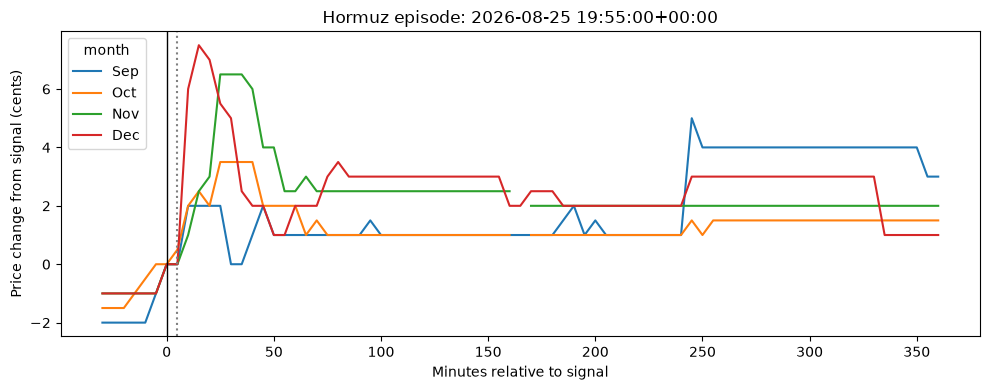

In [19]:
episode_number = 0
if len(events):
    episode_time = events.index[episode_number]
    episode = price5.loc[episode_time - pd.Timedelta(minutes=30):
                         episode_time + pd.Timedelta(hours=6)] - price5.loc[episode_time]
    episode.index = (episode.index - episode_time).total_seconds() / 60
    ax = episode.plot(figsize=(10, 4), title=f"Hormuz episode: {episode_time}")
    ax.axvline(0, color="black", linewidth=1)
    ax.axvline(5, color="grey", linestyle=":")
    ax.set(xlabel="Minutes relative to signal", ylabel="Price change from signal (cents)")
    plt.tight_layout()
    plt.show()
else:
    print("No episodes meet the chosen definition; do not tune it just to manufacture a result.")


### 20. A curved deadline fit, separate from the lead/lag test

Try a **logistic curve**: fit a straight line to log-odds, then convert it back to a price between 0 and 100 cents. It can bend without adding lots of parameters. We compare it with the earlier straight line on the same three snapshots.

Both fits use just two parameters. We clip probabilities only for the log calculation, not the observed prices; exact 0/1 would otherwise have infinite log-odds. The fitted line is not forced to slope upward.

A lower fit error only describes these four observed deadlines better. It **does not** show that an apparent underpriced December market will move toward the curve. A model can be wrong, and a curve can shift. With four points, we should not fit a high-degree polynomial and call its close fit an edge. This is not a survival model or an independently calibrated probability forecast.


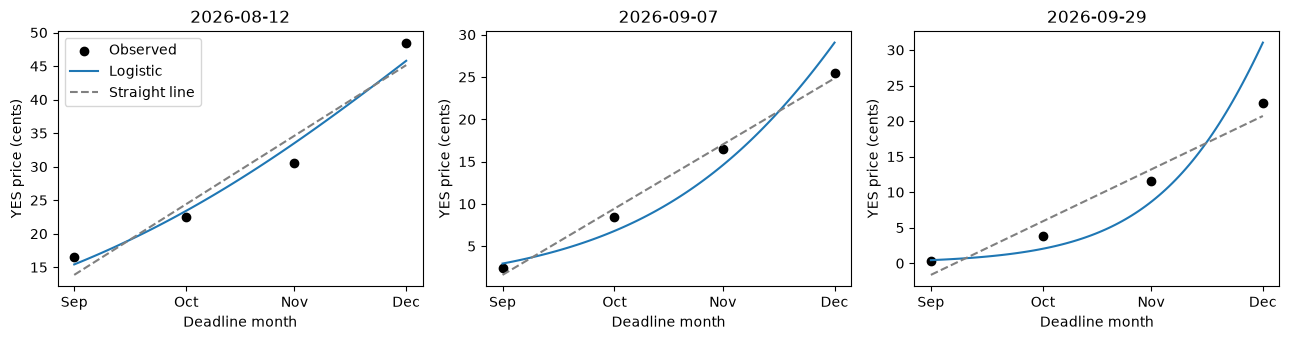

,straight_line_MAE_cents,logistic_MAE_cents
date,,
2026-08-12,3.000,1.926
2026-09-07,0.725,1.937
2026-09-29,1.838,3.367


In [20]:
curve_grid = np.linspace(days_from_september.min(), days_from_september.max(), 100)
fig, axes = plt.subplots(1, len(snapshot_dates), figsize=(13, 3.5))
fit_comparison = []
for ax, date in zip(axes, snapshot_dates):
    observed = complete_prices.loc[date].to_numpy()
    probability = np.clip(observed / 100, 0.0001, 0.9999)
    log_odds = np.log(probability / (1 - probability))
    curve_slope, curve_intercept = np.polyfit(days_from_september, log_odds, 1)
    curved = 100 / (1 + np.exp(-(curve_intercept + curve_slope * curve_grid)))
    fitted = 100 / (1 + np.exp(-(curve_intercept + curve_slope * days_from_september)))
    line_slope, line_intercept = np.polyfit(days_from_september, observed, 1)
    line_fit = line_intercept + line_slope * days_from_september
    ax.scatter(days_from_september, observed, color="black", label="Observed")
    ax.plot(curve_grid, curved, label="Logistic")
    ax.plot(days_from_september, line_fit, "--", color="grey", label="Straight line")
    ax.set_xticks(days_from_september, months)
    ax.set(title=str(date.date()), xlabel="Deadline month", ylabel="YES price (cents)")
    fit_comparison.append({"date": date.date(),
        "straight_line_MAE_cents": np.abs(observed - line_fit).mean(),
        "logistic_MAE_cents": np.abs(observed - fitted).mean()})
axes[0].legend()
plt.tight_layout()
plt.show()
display(pd.DataFrame(fit_comparison).set_index("date").round(3))


### What would count as useful evidence?

- Later-market gains should occur **after** the signal, not just during it, and look better than an appropriate baseline.
- The result should survive inspecting individual episodes, excluding the largest winner, checking later dates and allowing realistic trading costs.
- Heavy-flow episodes should have enough examples to compare; many fills may still belong to one participant.
- Timestamped news labels should be specified independently of subsequent returns before claiming a "special news" effect.
- A genuine trading test needs historical executable bid/ask prices and a locked rule evaluated on fresh data. These tables do not provide that.

For this saved run, the fixed rule found only **two separated episodes**, both in late August and potentially part of the same broader news episode. There were no qualifying later-half episodes and no lower-volume comparison episodes. That is far too little evidence to generalize. The logistic curve also did not improve fit error on every displayed snapshot.

**Stop and review the episode table together.** We have separated the hypotheses, not proven an edge or automatic arbitrage. All cells use saved data; no new market-data downloads or trades.


## Deadline-pair arbitrage: check the payoff before checking prices

### 21. Which pair is protected?

For an ideal pair where **YES by September implies YES by December**, one share of September **YES** plus one December **NO** can both lose: the qualifying event happens in October or November. Paying 60 + 30 cents then loses the entire 90 cents.

The protected direction is **September NO + December YES**. Under consistent, nested binary resolution, it pays at least 100 cents in total (and 200 cents in the middle case). Buying that pair for 90 cents would lock in at least 10 cents **before all costs and settlement risks**, if both legs can actually be bought.

Your quoted prices for the opposite pair do not imply the protected pair costs 90 cents. Under simple complementary displayed prices they would imply roughly 40 + 70 = 110 cents instead; actual buy asks need not be complementary.

The table assumes the same qualifying event, with only the deadline changing. For Hormuz, the event is the specified **PortWatch traffic threshold**, not merely an announcement that the strait has reopened. [Resolution follows the written market rules](https://docs.polymarket.com/concepts/resolution).


In [21]:
payoffs = pd.DataFrame({
    "qualifying_event": ["By September", "After September but by December", "Not by December"],
    "Sep_YES": [1, 0, 0],
    "Dec_YES": [1, 1, 0],
}).set_index("qualifying_event")
payoffs["Sep_YES_plus_Dec_NO_payout_cents"] = 100 * (payoffs["Sep_YES"] + 1 - payoffs["Dec_YES"])
payoffs["your_pair_profit_if_cost_90_cents"] = payoffs["Sep_YES_plus_Dec_NO_payout_cents"] - 90
payoffs["Sep_NO_plus_Dec_YES_payout_cents"] = 100 * (1 - payoffs["Sep_YES"] + payoffs["Dec_YES"])
display(payoffs.iloc[:, 2:])


,Sep_YES_plus_Dec_NO_payout_cents,your_pair_profit_if_cost_90_cents,Sep_NO_plus_Dec_YES_payout_cents
qualifying_event,,,
By September,100,10,100
After September but by December,0,-90,200
Not by December,100,10,100


### 22. Do the saved Hormuz rules support nesting?

The saved rules share a reviewed template, but each qualifying window starts at **that market's creation**. A later deadline alone does not establish nesting.

As a conservative screen, require the later market's creation time to be no later than the earlier market's, as well as the same reviewed template and a later deadline. December began in May, before the other three, so their qualifying windows fit inside December's. September began before October/November, so those later markets do not automatically contain September's whole qualifying window.

October and November were created about 49 seconds apart on the same day. A strict timestamp-containment check flags that pair for further interpretation of the date-based wording; this does **not** prove it is non-nested.

This is a window/template screen, not legal or oracle certification. Publication cutoffs, revisions, voids, disputes and actual settlement must still be checked before relying on a payout floor.


In [22]:
from itertools import combinations

pair_rows = []
for early, late in combinations(hormuz.itertuples(), 2):
    same_template = (early.rule_template_sha256 == late.rule_template_sha256
                     and early.rule_template_reviewed and late.rule_template_reviewed)
    contains_window = late.market_created_at_utc <= early.market_created_at_utc
    pair_rows.append({
        "pair": f"{early.month}/{late.month}",
        "early_id": early.market_id, "late_id": late.market_id,
        "both_open_from": max(early.api_start_date_utc, late.api_start_date_utc),
        "stop_before": min(pd.Timestamp(early.deadline_date, tz="UTC"),
                           pd.Timestamp(manifest["frozen_end_utc"])),
        "same_reviewed_template": same_template,
        "later_window_contains_earlier": contains_window,
        "passes_window_screen": same_template and contains_window,
    })
pair_rules = pd.DataFrame(pair_rows).set_index("pair")
display(pair_rules[["same_reviewed_template", "later_window_contains_earlier", "passes_window_screen"]])


,same_reviewed_template,later_window_contains_earlier,passes_window_screen
pair,,,
Sep/Oct,True,False,False
Sep/Nov,True,False,False
Sep/Dec,True,True,True
Oct/Nov,True,False,False
Oct/Dec,True,True,True
Nov/Dec,True,True,True


### 23. Screen actual NO + YES history observations

For all six Hormuz deadline pairs, add **earlier NO + later YES** at the **same saved timestamp and native resolution**. Use the observed NO series, not an invented `1 - YES` quote.

Check the saved 1-minute, 5-minute, 30-minute and 3-hour tiers separately. Do not interpolate, forward-fill, mix resolutions or assume we have every second. Start only after both API listing times; require the whole recorded bucket to end before the earlier deadline date (conservatively excluding that entire day), or before the frozen collection end.

`below_100` is a chart-price candidate only. These histories are not historical **ask quotes with available size**. Actual confirmation requires simultaneously buyable asks for equal shares, total costs below the payout floor, and validated rules. [Displayed prices and execution prices differ](https://docs.polymarket.com/concepts/prices-orderbook).

Different resolutions can describe the same episode. Do **not** add row counts together and call them independent arbitrages.


In [23]:
pair_history = prices[prices["family"].eq("hormuz_normalisation")
                      & prices["resolution_seconds"].gt(0)]
observed = pair_history.pivot(index=["timestamp_utc", "resolution_seconds"],
                              columns=["market_id", "outcome"], values="price") * 100
first_fills = hormuz_trades.groupby(["market_id", "outcome"])["timestamp_utc"].min()
scan_parts = []
for pair, rule in pair_rules.iterrows():
    matched = pd.DataFrame({
        "early_NO_cents": observed[(rule["early_id"], "No")],
        "late_YES_cents": observed[(rule["late_id"], "Yes")],
    }).dropna().reset_index()
    bucket_end = matched["timestamp_utc"] + pd.to_timedelta(matched["resolution_seconds"], unit="s")
    matched = matched[matched["timestamp_utc"].ge(rule["both_open_from"])
                      & bucket_end.lt(rule["stop_before"])].copy()
    matched["pair"] = pair
    matched["cost_cents"] = matched["early_NO_cents"] + matched["late_YES_cents"]
    matched["below_100"] = matched["cost_cents"].lt(100 - 1e-8)
    matched["passes_window_screen"] = rule["passes_window_screen"]
    matched["both_legs_have_prior_saved_fill"] = (
        matched["timestamp_utc"].ge(first_fills.get((rule["early_id"], "No"), pd.NaT))
        & matched["timestamp_utc"].ge(first_fills.get((rule["late_id"], "Yes"), pd.NaT)))
    scan_parts.append(matched)

pair_scan = pd.concat(scan_parts, ignore_index=True)
scan_summary = pair_scan.groupby(["pair", "resolution_seconds"]).agg(
    matched_points=("cost_cents", "size"), min_cost_cents=("cost_cents", "min"),
    below_100_points=("below_100", "sum"))
display(scan_summary.round(3))


matched_points  min_cost_cents  below_100_points
pair    resolution_seconds                                                  
Nov/Dec 60                           11325          104.00                 0
        300                          15243           94.50                 8
        1800                          2541           94.50                 2
        10800                          417          103.00                 0
Oct/Dec 60                           11325          110.00                 0
        300                          15177          108.50                 0
        1800                          2540          109.00                 0
        10800                          417          109.00                 0
Oct/Nov 60                           11327          104.00                 0
        300                          15188           97.00                 3
        1800                          2545          101.50                 0
        10800                          420          101.50                 0
Sep/Dec 60                            6175          118.95                 0
        300                          15923          113.25                 0
        1800                          2903          113.25                 0
        10800                          676          113.95                 0
Sep/Nov 60                            6175          110.25                 0
        300                          14116          107.00                 0
        1800                          2370          107.05                 0
        10800                          389          107.05                 0
Sep/Oct 60                            6175          103.25                 0
        300                          14118          103.25                 0
        1800                          2370          103.45                 0
        10800                          389          103.50                 0

### 24. Inspect the candidates, including their opening-period context

The first table gives the cheapest observed combination for each pair. The next shows every sub-100 observation retained by the screen.

`both_legs_have_prior_saved_fill` is only a diagnostic: absence of a saved fill does not prove there was no quote, and a prior fill does not prove a current quote was executable. It helps identify prices from a new market's opening period.

**Saved-data finding with this screen:** September NO + December YES never went below 100 cents; its lowest matched observed cost was **113.25 cents**. November NO + December YES reached **94.5 cents** (a 5.5-cent chart gap), and October NO + November YES reached **97 cents** (a 3-cent chart gap, with the additional rule-window check outstanding).

All sub-100 observations were on **August 11**, before the first saved fills in the newly listed leg(s), which begin around 11:50 UTC. They are unconfirmed opening-period readings, **not verified executable profits**. There were no sub-100 candidates after both legs had at least one saved fill. This does not rule out opportunities between observations or at unavailable resolutions.


In [24]:
best_rows = pair_scan.loc[pair_scan.groupby("pair")["cost_cents"].idxmin()]
display(best_rows[["pair", "timestamp_utc", "resolution_seconds", "early_NO_cents",
                   "late_YES_cents", "cost_cents", "passes_window_screen"]])

pair_candidates = pair_scan[pair_scan["below_100"]].copy()
pair_candidates["gap_to_100_cents"] = 100 - pair_candidates["cost_cents"]
display(pair_candidates[["pair", "timestamp_utc", "resolution_seconds", "cost_cents",
                         "gap_to_100_cents", "passes_window_screen",
                         "both_legs_have_prior_saved_fill"]].sort_values(["pair", "timestamp_utc"]))
print("Candidate observations after both legs' first saved fills:",
      pair_candidates["both_legs_have_prior_saved_fill"].sum())
print("Confirmed executable arbitrages: not measurable from these price-history tables.")


,pair,timestamp_utc,resolution_seconds,early_NO_cents,late_YES_cents,cost_cents,passes_window_screen
130719,Nov/Dec,2026-08-11 09:30:00+00:00,300,48.00,46.5,94.50,True
111459,Oct/Dec,2026-09-10 10:35:00+00:00,300,94.00,14.5,108.50,True
71791,Oct/Nov,2026-08-11 10:15:00+00:00,300,70.50,26.5,97.00,False
58894,Sep/Dec,2026-09-10 10:35:00+00:00,300,98.75,14.5,113.25,True
33351,Sep/Nov,2026-09-10 19:40:00+00:00,300,98.50,8.5,107.00,False
21108,Sep/Oct,2026-09-28 21:44:00+00:00,60,99.75,3.5,103.25,False


,pair,timestamp_utc,resolution_seconds,cost_cents,gap_to_100_cents,passes_window_screen,both_legs_have_prior_saved_fill
130718,Nov/Dec,2026-08-11 09:25:00+00:00,300,96.5,3.5,True,False
130719,Nov/Dec,2026-08-11 09:30:00+00:00,300,94.5,5.5,True,False
130720,Nov/Dec,2026-08-11 09:30:00+00:00,1800,94.5,5.5,True,False
130721,Nov/Dec,2026-08-11 09:35:00+00:00,300,94.5,5.5,True,False
130722,Nov/Dec,2026-08-11 09:40:00+00:00,300,94.5,5.5,True,False
130723,Nov/Dec,2026-08-11 09:45:00+00:00,300,94.5,5.5,True,False
130724,Nov/Dec,2026-08-11 09:50:00+00:00,300,94.5,5.5,True,False
130725,Nov/Dec,2026-08-11 09:55:00+00:00,300,95.0,5.0,True,False
130726,Nov/Dec,2026-08-11 10:00:00+00:00,300,95.5,4.5,True,False
130727,Nov/Dec,2026-08-11 10:00:00+00:00,1800,95.5,4.5,True,False


Candidate observations after both legs' first saved fills: 0
Confirmed executable arbitrages: not measurable from these price-history tables.
